In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# cargar el dataset 
df = pd.read_csv('../datos/partidos_cebollitas_fe82a1a4-e109-41b1-8b78-d9b4341dacaf.csv')

df.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


In [20]:
# variables que ayudaran en el modelo
df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
df['diferencia_posesion'] = df['posesion_local (%)'] - df['posesion_visitante (%)']
df['eficiencia_tiros_local'] = df['goles_local'] / (df['tiros_arco_local'] + 1e-5)
df['eficiencia_tiros_visitante'] = df['goles_visitante'] / (df['tiros_arco_visitante'] + 1e-5)
df['local_es_cebollitas'] = (df['equipo_local'] == 'Cebollitas FC').astype(int)


In [21]:
# se eligen las variablesmas informativas 
features = [
    'posesion_local (%)', 'tiros_arco_local', 'diferencia_posesion',
    'eficiencia_tiros_local', 'eficiencia_tiros_visitante',
    'local_es_cebollitas'
] + [col for col in df.columns if col.startswith("estadio_")]

X = df[features]
y = df['diferencia_goles']

In [22]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# se entrena el modelo random forest 
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# se hacen predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [ ]:
# metricas de evaluacion
from sklearn.metrics import mean_absolute_error


rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R²: {r2_rf:.2f}")

RMSE: 0.95
MAE: 0.73
R²: 0.81


/tmp/ipykernel_10721/1737417635.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', color='darkgreen')


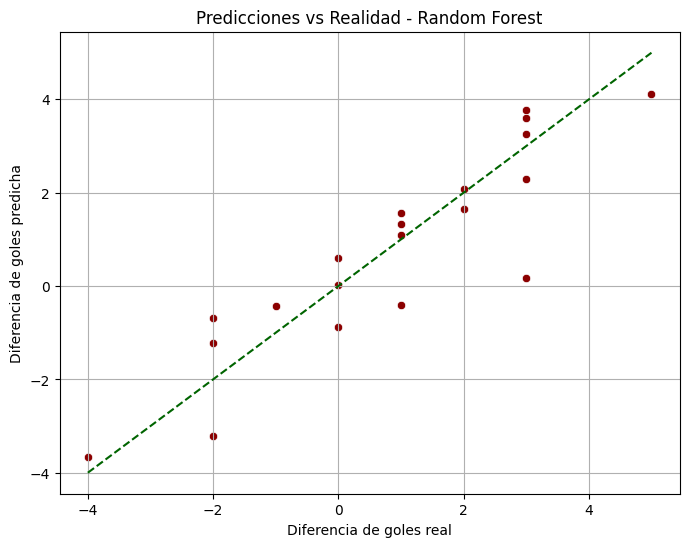

In [28]:
# grafico de demostracion
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', color='darkgreen')
plt.xlabel("Diferencia de goles real")
plt.ylabel("Diferencia de goles predicha")
plt.title("Predicciones vs Realidad - Random Forest")
plt.grid(True)
plt.show()